# GPT 模型的训练与评估

## 介绍

在前面的章节中，我们已经系统地完成了预训练数据集的构建、GPT模型架构的完整定义以及文本生成解码方法的实现。本节将正式启动 GPT 模型的训练流程，旨在让模型学习语言的统计规律与深层知识，并对其训练效果进行评估。

![image.png](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260315143858.png)



## 环境配置

### 安装依赖

In [ ]:
!pip install --upgrade dsxllm

### 环境版本

In [2]:
from dsxllm.util import show_version

show_version()

本书愿景：
+------+--------------------------------------------------------+
| Info |                  《动手学大语言模型》                  |
+------+--------------------------------------------------------+
| 作者 |                       吾辈亦有感                       |
| 哔站 |      https://space.bilibili.com/3546632320715420       |
| 定位 | 基于'从零构建'的理念，用实战帮助程序员快速入门大模型。 |
| 愿景 | 若让你的AI学习之路走的更容易一点，我将倍感荣幸！祝好😄 |
+------+--------------------------------------------------------+
环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.10.0    |         2.6.1          |
+-------------+--------------+------------------------+


## GPT 模型的训练与评估

### 训练与生成阶段的区别

GPT 的自回归任务是根据已生成的 Token 序列预测下一个 Token，但它在训练和生成阶段的行为是不同的。

- **在训练阶段**：正确的 Token IDs 是已知的，因此无论预测的结果如何，模型都会根据正确的信息预测下一个 Token。
- **在生成阶段**：正确的 Token IDs 是未知的，因此模型会根据自己预测的序列信息预测下一个 Token。

训练阶段的输入如下图所示：

![image.png](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260315144056.png)

生成阶段的输入如下图所示：

![image.png](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260315144101.png)

在训练阶段，模型的输入是正确的句子对应的 Token ID，它的每一个值都是确定的，所以可以批量进行计算，而不用像生成解码时那样，每次只能计算一个 Token，再用新的 Token 作为输入继续后面的预测。


### 如何评估生成模型的好坏？

假设有两个训练好的模型，当输入 `动` 时，模型预测的下一个词都是 `手`，下一个词的概率分布如下图所示：

![image.png](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260315144723.png)

那么，两个语言模型哪一个更好呢？通过对比可知，模型 1 明显优于模型 2。因为型 1 为正确下一个词分配了更高的概率，其预测更加精准和确定。

在评估语言模型时，我们可以引入一个困惑度（Perplexity, PPL）的指标，它量化了模型在预测序列中下一个词元（Token）时的不确定性。其核心思想是：困惑度越低，表明模型对语言的统计规律掌握得越好，预测越准确。

下一个词的困惑度等于模型对该词的预测概率的倒数。模型 1 预测 `手` 的概率是 0.8，那么模型 1 的困惑度就是 $1/0.8 = 1.25$。模型 2 预测 `手` 的概率是 0.4，那么模型 2 的困惑度就是 $1/0.4 = 2.5$。

如何直观地解释值 1.25 和 2.5 呢？它们可以解释为“分叉度”。所谓分叉度，是指下一个可以选择的选项的数量（下一个可能出现的单词的候选个数）。

然而，需要指出的是，困惑度虽然是一个强大且常用的指标，但也有其局限性。它严重依赖于模型所使用的词表（Tokenizer），不同词表的模型其困惑度不能直接比较。更重要的是，困惑度主要衡量模型对词序列统计规律的掌握（即流畅度），并不能保证生成内容的语义正确性、事实准确性或逻辑连贯性。一个模型可能生成语法流畅但内容荒谬的句子，同时保持较低的困惑度。因此，在最终评估模型时，通常还需要结合具体下游任务（如翻译、问答）的指标进行综合判断。  

### 如何计算句子生成的困惑度？

困惑度（PPL）本质上就是在衡量模型在预测下一个词时的“有效平均选择数”。困惑度与交叉熵（CE）存在直接的指数关系：

$$
\text{PPL} = \exp\left( -\frac{1}{N} \sum_{i=1}^{N} \log P(w_i \mid w_1, \dots, w_{i-1}) \right) = \exp(\text{CE})
$$

其中：
- $N$ 是句子中词（或子词）的个数；
- $P(w_i \mid w_1, \dots, w_{i-1})$ 是语言模型根据前文预测当前词 $w_i$ 的条件概率；
- $\text{CE}$ 表示平均交叉熵，即每个词的平均负对数似然。

该公式表明，困惑度是交叉熵的指数函数，两者在优化目标上完全一致：**最小化交叉熵等价于最小化困惑度**。交叉熵给出线性尺度的“平均惊奇度”，而困惑度将其转换为更直观的“有效候选词数量”。所以，在后面的训练过程中，我们会优化模型的交叉熵，并使用损失的变化来评估模型的训练效果。

## 添加训练和评估方法

In [1]:
import lightning as L
import torch
from dsxllm.gpt.layer import TransformerBlock, LayerNorm


class GPTModel(L.LightningModule):
    """
    GPT 语言模型，基于 Transformer 解码器架构。

    模型结构：
        - Token Embedding：将 token ID 映射为 d_model 维向量
        - Position Embedding：为每个位置添加可学习的位置编码
        - Dropout：对嵌入向量进行正则化
        - Transformer 块堆叠：多个 TransformerBlock
        - 最终层归一化
        - 输出线性层（LM Head）：将 d_model 映射回词汇表大小

    Args:
        cfg (dict): 配置字典，必须包含以下键：
            - vocab_size: 词汇表大小
            - d_model: 嵌入维度
            - seq_len: 最大上下文长度
            - drop_rate: Dropout 概率
            - n_layers: Transformer 块的数量
    """

    def __init__(self, cfg):
        super().__init__()

        # Token 嵌入层
        self.token_embedding = torch.nn.Embedding(cfg["vocab_size"], cfg["d_model"])

        # 位置嵌入层
        self.position_embedding = torch.nn.Embedding(cfg["seq_len"], cfg["d_model"])

        # 嵌入后的 Dropout
        self.embedding_dropout = torch.nn.Dropout(cfg["drop_rate"])

        # Transformer 块堆叠
        self.transformer_blocks = torch.nn.Sequential(
            *[
                TransformerBlock(
                    d_model=cfg["d_model"],
                    seq_len=cfg["seq_len"],
                    n_heads=cfg["n_heads"],
                    drop_rate=cfg["drop_rate"],
                    qkv_bias=cfg["qkv_bias"],
                )
                for _ in range(cfg["n_layers"])
            ]
        )

        # 最终层归一化
        self.final_layer_norm = LayerNorm(cfg["d_model"])

        # 输出层（语言模型头），无偏置
        self.lm_head = torch.nn.Linear(cfg["d_model"], cfg["vocab_size"], bias=False)

        # 用于记录训练和验证过程中的损失
        self.train_step_losses = []  # 每个 step 的损失
        self.train_epoch_losses = []  # 每个 epoch 的平均损失
        self.val_step_losses = []  # 每个 step 的验证损失
        self.val_epoch_losses = []  # 每个 epoch 的平均验证损失

        # 示例输入
        self.example_input_array = torch.randint(
            0, cfg["vocab_size"], (2, cfg["seq_len"])
        )

    def forward(self, input_ids):
        """
        前向传播，计算下一个 token 的 logits。

        Args:
            input_ids (torch.Tensor): 输入 token ID 序列，形状为 (batch_size, seq_len)

        Returns:
            torch.Tensor: 预测 logits，形状为 (batch_size, seq_len, vocab_size)
        """
        batch_size, seq_len = input_ids.shape
        device = input_ids.device

        # Token 嵌入
        token_embeds = self.token_embedding(input_ids)  # (batch, seq_len, d_model)

        # 位置嵌入（生成位置索引 [0, 1, ..., seq_len-1]）
        position_ids = torch.arange(seq_len, device=device)
        position_embeds = self.position_embedding(position_ids)  # (seq_len, d_model)

        # 将 token 嵌入和位置嵌入相加，得到最终的输入表示，形状为 (batch, seq_len, d_model)
        hidden_states = token_embeds + position_embeds

        # 应用 Dropout
        hidden_states = self.embedding_dropout(hidden_states)

        # 通过所有 Transformer 块
        hidden_states = self.transformer_blocks(hidden_states)

        # 最终层归一化
        hidden_states = self.final_layer_norm(hidden_states)

        # 通过语言模型头得到 logits，形状为 (batch, seq_len, vocab_size)
        logits = self.lm_head(hidden_states)

        return logits

    def training_step(self, batch, batch_idx):
        """
        单个训练步骤。计算损失并记录。

        Args:
            batch: 由 DataLoader 返回的批次，包含 (input_ids, target_ids)
            batch_idx: 批次索引

        Returns:
            torch.Tensor: 损失值
        """
        # 从批次中提取输入和目标 ID
        input_ids, target_ids = batch

        # 前向传播，计算 logits，形状为 (batch, seq_len, vocab_size)
        # 这里的 input_ids 是提前构建好的，无论模型输出结果如何都不会改变，所以可以直接传入模型，批量进行计算
        logits = self(input_ids)

        # 计算交叉熵损失（将 logits 和 targets 展平）
        loss = torch.nn.functional.cross_entropy(
            logits.view(-1, logits.size(-1)), target_ids.view(-1)
        )

        # 记录当前 step 的损失（detach 避免梯度累积）
        self.train_step_losses.append(loss.detach())

        # 记录到 Lightning 日志
        self.log("train_step_loss", loss.detach())

        return loss

    def on_train_epoch_end(self):
        """每个训练 epoch 结束时计算平均损失并记录。"""
        if self.train_step_losses:
            avg_loss = torch.stack(self.train_step_losses).mean()
            self.print(
                f"***** 【Epoch {self.current_epoch}】 Train Avg Loss: {avg_loss:.4f} *****"
            )
            self.train_epoch_losses.append(
                {"epoch": self.current_epoch, "loss": avg_loss.item()}
            )

            # 清空 step 列表，为下一 epoch 做准备
            self.train_step_losses.clear()

    def configure_optimizers(self):
        """配置优化器（AdamW）。"""
        optimizer = torch.optim.AdamW(self.parameters(), lr=0.0004, weight_decay=0.01)
        return optimizer

    def validation_step(self, batch, batch_idx):
        """单个验证步骤。"""
        input_ids, target_ids = batch
        logits = self(input_ids)
        loss = torch.nn.functional.cross_entropy(
            logits.view(-1, logits.size(-1)), target_ids.view(-1)
        )
        self.val_step_losses.append(loss.detach())
        self.log("val_step_loss", loss.detach(), on_step=True, on_epoch=False)
        return loss

    def on_validation_epoch_end(self):
        """每个验证 epoch 结束时计算平均损失并记录。"""
        if self.val_step_losses:
            avg_loss = torch.stack(self.val_step_losses).mean()
            self.print(
                f"***** 【Epoch {self.current_epoch}】 Val Avg Loss: {avg_loss:.4f} *****"
            )
            self.val_epoch_losses.append(
                {"epoch": self.current_epoch, "loss": avg_loss.item()}
            )
            # 清空 step 列表，为下一 epoch 做准备
            self.val_step_losses.clear()

    def clear_loss_history(self):
        """清空所有缓存的损失列表，释放内存。"""
        self.train_step_losses.clear()
        self.train_epoch_losses.clear()
        self.val_step_losses.clear()
        self.val_epoch_losses.clear()

/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 开始训练 GPT 模型

### 配置 GPT 模型参数

In [2]:
# 定义GPT模型的配置参数（对应124M参数版本的GPT）
GPT_CONFIG_124M = {
    "vocab_size": 50257,  # 词汇表大小，即模型可以表示的不同token的数量
    "seq_len": 256,  # 上下文长度（原为1024，此处缩短为256），决定模型一次处理的最大序列长度
    "d_model": 768,  # 嵌入维度（embedding dimension），每个token被映射到的向量维度
    "n_heads": 12,  # 注意力头数量（number of attention heads），用于多头注意力机制
    "n_layers": 12,  # 层数，Transformer块的数量
    "drop_rate": 0.1,  # Dropout率，用于防止过拟合的概率值
    "qkv_bias": False,  # 查询-键-值偏置（query-key-value bias），是否在注意力计算中使用偏置项
}

### 添加生成测试回调

在每个评估 epoch 结束时，我们会生成一个样本，以便于直观观察模型的生成能力的提升。

In [ ]:
from dsxllm.gpt.tokenizer import text_to_token_ids
from dsxllm.gpt.model import greedy_generate
from dsxllm.util import print_table
import lightning as L


class SampleTestCallback(L.Callback):
    def __init__(self, tokenizer, context_size, start_token="I"):
        self.tokenizer = tokenizer
        self.start_token = start_token
        self.context_size = context_size

    def on_validation_epoch_end(self, trainer, pl_module):
        """每个验证 epoch 结束时调用，生成文本并打印。"""

        # 使用贪心解码生成文本
        generated_text = greedy_generate(
            model=pl_module,
            start_ids=text_to_token_ids(self.start_token, self.tokenizer),
            max_new_tokens=10,
            context_size=self.context_size,
            tokenizer=self.tokenizer,
        )

        # 打印生成的文本
        print_table(
            table_name="生成测试",
            field_names=["Epoch", "Start_Token", "Generated_Text"],
            data=[[trainer.current_epoch, self.start_token, generated_text]],
        )

### 初始化 GPT 模型和训练器

In [ ]:
import lightning as L

import tiktoken

from dsxllm.gpt.dataset import GPTDataModule
from dsxllm.gpt.model import GPTModel, SampleTestCallback


# 超参配置：
num_epochs = 10
batch_size = 4
max_length = GPT_CONFIG_124M["seq_len"]
stride = GPT_CONFIG_124M["seq_len"]


# 1️⃣ 初始化 GPT-2 使用的分词器
tokenizer = tiktoken.get_encoding("gpt2")

# 3️⃣ 加载数据模组
data_filepath = "./dataset/llm_corpus.txt"
datamodule = GPTDataModule(
    batch_size=batch_size,
    tokenizer=tokenizer,
    train_data_file=data_filepath,
    max_length=max_length,
    stride=stride,
)

# 4️⃣ 初始化模型
model = GPTModel(GPT_CONFIG_124M)

# 5️⃣ 初始化训练器
trainer = L.Trainer(
    max_epochs=20,
    log_every_n_steps=3,
    check_val_every_n_epoch=1,
    num_sanity_val_steps=0,
    enable_progress_bar=False,
    callbacks=[SampleTestCallback(tokenizer, context_size=max_length)],
    enable_checkpointing=False,
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### 训练 GPT 模型

In [5]:
trainer.fit(model=model, datamodule=datamodule)

┏━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃   ┃ Name               ┃ Type       ┃ Params ┃ Mode  ┃  FLOPs ┃      In sizes ┃       Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ 0 │ token_embedding    │ Embedding  │ 38.6 M │ train │      0 │      [2, 256] │   [2, 256, 768] │
│ 1 │ position_embedding │ Embedding  │  196 K │ train │      0 │         [256] │      [256, 768] │
│ 2 │ embedding_dropout  │ Dropout    │      0 │ train │      0 │ [2, 256, 768] │   [2, 256, 768] │
│ 3 │ transformer_blocks │ Sequential │  113 M │ train │  120 B │ [2, 256, 768] │   [2, 256, 768] │
│ 4 │ final_layer_norm   │ LayerNorm  │  1.5 K │ train │      0 │ [2, 256, 768] │   [2, 256, 768] │
│ 5 │ lm_head            │ Linear     │ 38.6 M │ train │ 39.5 B │ [2, 256, 768] │ [2, 256, 50257] │
└───┴────────────────────┴────────────┴────────┴───────┴────────┴───────────────┴─────────────────┘

Trainable params: 190 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 190 M                                                                                                
Total estimated model params size (MB): 762                                                                        
Modules in train mode: 186                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 160 B

/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


生成测试：
+-------+-------------+----------------+
| Epoch | Start_Token | Generated_Text |
+-------+-------------+----------------+
|   0   |      I      |       I        |
|       |             |                |
|       |             |                |
|       |             |                |
|       |             |                |
|       |             |                |
|       |             |                |
|       |             |                |
|       |             |                |
|       |             |                |
|       |             |                |
+-------+-------------+----------------+
***** 【Epoch 0】 Val Avg Loss: 8.7309 *****
***** 【Epoch 0】 Train Avg Loss: 9.9187 *****
生成测试：
+-------+-------------+----------------+
| Epoch | Start_Token | Generated_Text |
+-------+-------------+----------------+
|   1   |      I      |  I,,,,,,,,,,   |
+-------+-------------+----------------+
***** 【Epoch 1】 Val Avg Loss: 7.8080 *****
***** 【Epoch 1】 Train Avg Loss: 8.088

`Trainer.fit` stopped: `max_epochs=20` reached.


生成测试：
+-------+-------------+--------------------------------------------+
| Epoch | Start_Token |               Generated_Text               |
+-------+-------------+--------------------------------------------+
|   19  |      I      | I HAD always thought Jack Gisburn rather a |
+-------+-------------+--------------------------------------------+
***** 【Epoch 19】 Val Avg Loss: 6.4593 *****
***** 【Epoch 19】 Train Avg Loss: 0.5163 *****


从模型的训练过程中，我们可以看到模型生成测试从最初的胡乱生成到最后逐渐生成了有意义的句子，说明咱们的 GPT 模型的确实从训练中学习到了语言的规则，具备了一定的语言理解能力。

### 可视化训练过程

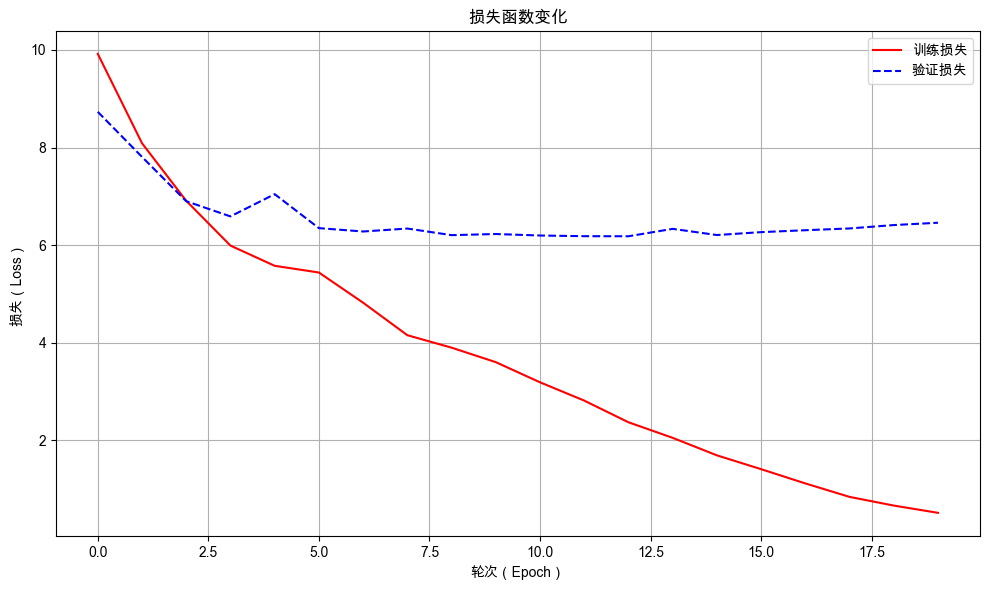

In [6]:
from dsxllm.util import plot_loss_curves

plot_loss_curves(model.train_epoch_losses, model.val_epoch_losses)

## 答疑讨论

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('qa'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/logo.png" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">答疑讨论</h4>
                <p class="card-text">
                    如果你有任何学习上的疑问，可以评论留言，和我一起讨论。我会抽空回复你的问题，也欢迎你回答其他人的问题。
                </p>
            </div>
        </div>
    </div>
</a>
```